IMPORTING ALL OF THE IMPORTANT STUFF

In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from shahEDA import analyze

LOADING DATASET

In [4]:
df = pd.read_csv("salary.csv")
df.shape

(15, 5)

EDA (EXPLORATORY DATA ANALYSIS)

In [5]:
eda = analyze("salary.csv", verbose=True)

Loaded file in csv format


In [6]:
eda["stats"]

{'mean': age                  32.800000
 experience            8.000000
 hours_per_week       50.933333
 salary            68733.333333
 dtype: float64,
 'median': age                  30.0
 experience            7.0
 hours_per_week       50.0
 salary            60000.0
 dtype: float64,
 'mode': age                       22
 experience               3.0
 education_level    Bachelors
 hours_per_week          40.0
 salary                 25000
 Name: 0, dtype: object,
 'std': age                   8.427845
 experience            5.424811
 hours_per_week        9.691430
 salary            35388.591113
 dtype: float64,
 'variance': age               7.102857e+01
 experience        2.942857e+01
 hours_per_week    9.392381e+01
 salary            1.252352e+09
 dtype: float64,
 'summary':              age  experience  hours_per_week         salary
 count  15.000000   15.000000       15.000000      15.000000
 mean   32.800000    8.000000       50.933333   68733.333333
 std     8.427845    5.424

In [7]:
eda["duplicates"]

np.int64(0)

In [8]:
eda["missing"]

age                0
experience         0
education_level    0
hours_per_week     0
salary             0
dtype: int64

EDA WITH THE SEABORN (graphs)

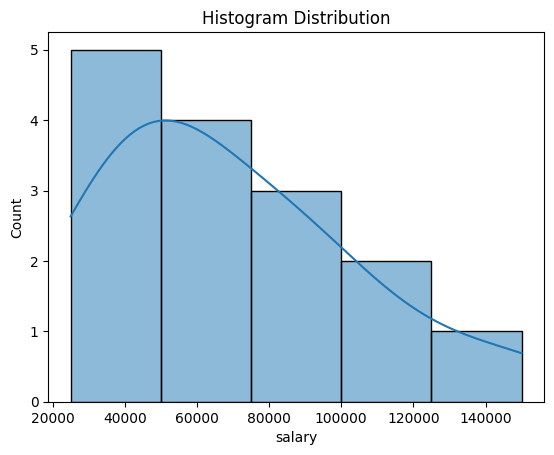

In [9]:
sns.histplot(df["salary"], kde=True)
plt.title("Histogram Distribution")
plt.show()

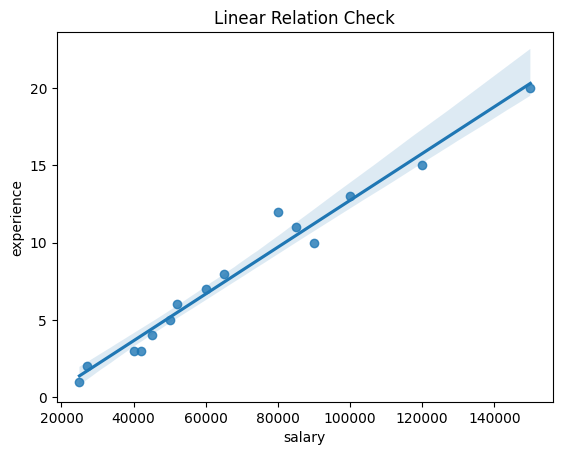

In [10]:
sns.regplot(x='salary', y='experience', data=df)
plt.title("Linear Relation Check")
plt.show()

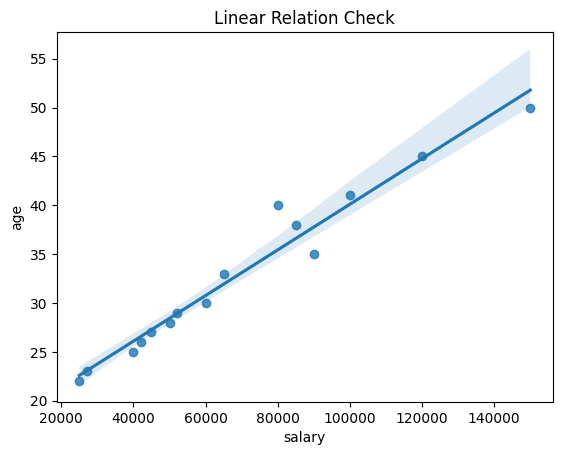

In [11]:
sns.regplot(x='salary', y='age', data=df)
plt.title("Linear Relation Check")
plt.show()

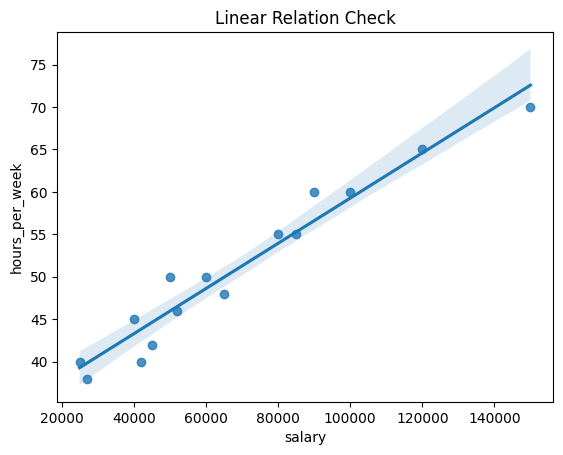

In [12]:
sns.regplot(x='salary', y='hours_per_week', data=df)
plt.title("Linear Relation Check")
plt.show()

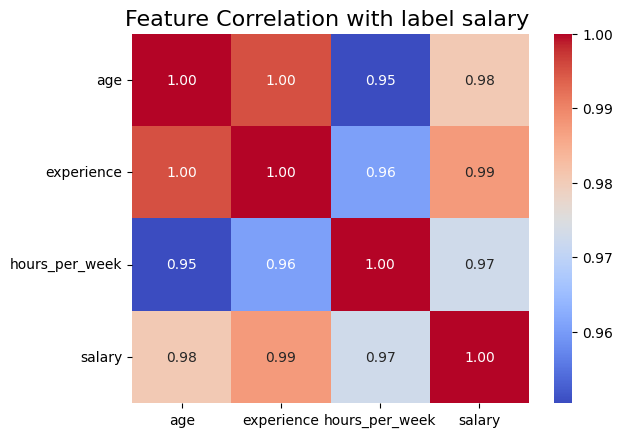

In [13]:
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Feature Correlation with label salary ', fontdict={'fontsize':16})
plt.show()

MODELS CREATIONS AND COMPARRISIONS

In [14]:
#MODEL-1 (experience feature only (Linear Regression))
X = df[["experience"]]
Y = df["salary"]

In [15]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error

In [16]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)


In [17]:
X_test.shape

(3, 1)

In [18]:

X_train.shape

(12, 1)

In [19]:
Y_test.shape

(3,)

In [20]:
Y_train.shape

(12,)

In [21]:
linear_model = LinearRegression()
linear_model.fit(X_train,Y_train)
Y_pred = linear_model.predict(X_test)
r2_linear = r2_score(Y_test, Y_pred)
mae_linear = mean_absolute_error(Y_test, Y_pred)
print(f"r2 score for: {r2_linear*100:.2f}")
print(f"Mean Error for :{mae_linear:.2f}")


r2 score for: 94.54
Mean Error for :2498.02


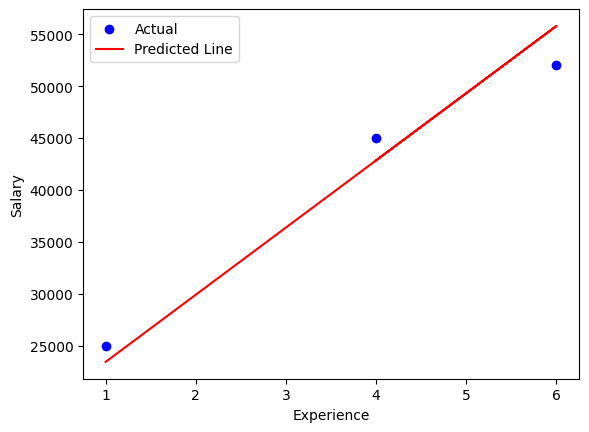

In [22]:
plt.scatter(X_test, Y_test, color="blue", label="Actual")
plt.plot(X_test, Y_pred, color="red", label="Predicted Line")
plt.xlabel("Experience")
plt.ylabel("Salary")
plt.legend()
plt.show()

In [23]:
#MODEL-2 (ALL features (Linear Regression))
X_model2 = df.drop(columns=["salary"])
X_model2 = pd.get_dummies(X_model2, columns=['education_level'], drop_first=True)
Y_model2 = df['salary']

In [24]:
X_model2.head(5)

,age,experience,hours_per_week,education_level_Masters,education_level_PhD
0,22,1,40,False,False
1,25,3,45,True,False
2,28,5,50,False,False
3,35,10,60,False,True
4,40,12,55,True,False


In [25]:
X_model2.columns

Index(['age', 'experience', 'hours_per_week', 'education_level_Masters',
       'education_level_PhD'],
      dtype='str')

In [26]:
X_train2, X_test2, Y_train2, Y_test2 = train_test_split(X_model2, Y_model2, test_size=0.2, random_state=42)
linear_model2 = LinearRegression()
linear_model2.fit(X_train2, Y_train2)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [27]:
Y_pred2 = linear_model2.predict(X_test2)
r2_linear2 = r2_score(Y_test2, Y_pred2)
mae2 = mean_absolute_error(Y_test2, Y_pred2)
print(f"R² Score: {r2_linear2*100:.2f}")
print(f"MAE: {mae2:.2f}")

R² Score: 95.22
MAE: 2420.25


In [28]:
X_test2.shape
Y_test2

9     45000
11    52000
0     25000
Name: salary, dtype: int64

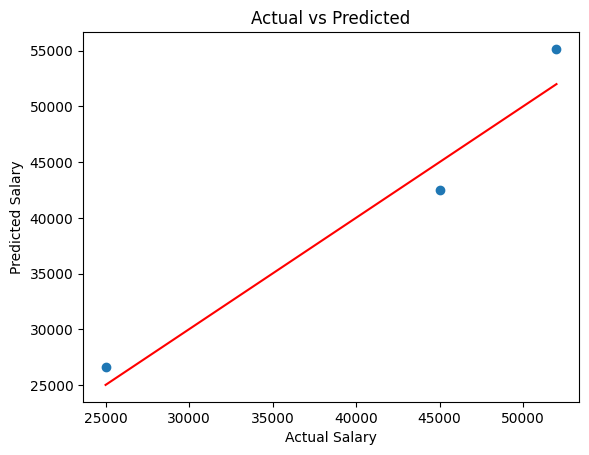

In [29]:
plt.scatter(Y_test2, Y_pred2)
plt.xlabel("Actual Salary")
plt.ylabel("Predicted Salary")
plt.title("Actual vs Predicted")
plt.plot([Y_test2.min(), Y_test2.max()],
         [Y_test2.min(), Y_test2.max()],
         color='red')
plt.show()

In [30]:
#MODEL-3 (ALL features (Random Forest))
from sklearn.ensemble import RandomForestRegressor
X_model3 = df.drop(columns=["salary"])
X_model3 = pd.get_dummies(X_model3, columns=['education_level'], drop_first=True)
Y_model3 = df['salary']

In [31]:
X_train3, X_test3, Y_train3, Y_test3 = train_test_split(X_model3, Y_model3)

In [32]:
rf = RandomForestRegressor()
rf.fit(X_train3, Y_train3)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [33]:
Y_pred3 = rf.predict(X_test3)
r2_rf = r2_score(Y_test3, Y_pred3)
mae3 = mean_absolute_error(Y_test3, Y_pred3)
print(f"R² Score: {r2_linear2*100:.2f}")
print(f"MAE: {mae3:.2f}")

R² Score: 95.22
MAE: 7497.50


In [36]:
X_train2.columns

Index(['age', 'experience', 'hours_per_week', 'education_level_Masters',
       'education_level_PhD'],
      dtype='str')

EXPORTING THE 2ND MODEL (WITH ALL FEATURE + LINEAR REGRESSION)

In [37]:
import joblib
# Save model
joblib.dump(linear_model2, "salary_model.pkl")
# Save column names
joblib.dump(X_train2.columns.tolist(), "model_columns.pkl")

['model_columns.pkl']